# Layer 7: Correlation & Competition Analysis

**Section 3.4:** City-wise price correlation, cross-store synchronization

**Input:** `data/matched/matched_products.csv`

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

# --- Premium Global Styling ---
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.edgecolor':   '#ced4da',
    'axes.labelcolor':  '#212529',
    'axes.titleweight': 'bold',
    'axes.titlesize':   18,
    'axes.labelsize':   12,
    'font.family':      'sans-serif',
    'grid.color':       '#dee2e6',
    'grid.linestyle':   '--'
})
sns.set_theme(style='whitegrid', font_scale=1.1)
STORE_COLORS = {'Al-Fatah': '#3366cc', 'Metro': '#109618', 'Chase Up': '#ff9900'}
BASE_DIR = Path(os.getcwd()).parent
FIGURES_DIR = BASE_DIR / 'results' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
# ------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from pathlib import Path
import os

plt.rcParams.update({'figure.facecolor':'#fafafa','axes.facecolor':'#fafafa','axes.titleweight':'bold','axes.titlesize':16})
sns.set_theme(style='whitegrid')
sns.set_context('talk')
STORE_COLORS = {'Al-Fatah': '#3366cc', 'Metro': '#109618', 'Chase Up': '#ff9900'}

BASE_DIR    = Path(os.getcwd()).parent
FIGURES_DIR = BASE_DIR / 'results' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(BASE_DIR / 'data' / 'matched' / 'matched_products.csv', low_memory=False)
print(f'Loaded {len(df):,} matched rows | Products: {df["product_id"].nunique():,}')
# --- Premium Global Styling ---
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.edgecolor':   '#ced4da',
    'axes.labelcolor':  '#212529',
    'axes.titleweight': 'bold',
    'axes.titlesize':   18,
    'axes.labelsize':   12,
    'font.family':      'sans-serif',
    'grid.color':       '#dee2e6',
    'grid.linestyle':   '--'
})
sns.set_theme(style='whitegrid', font_scale=1.1)
STORE_COLORS = {'Al-Fatah': '#3366cc', 'Metro': '#109618', 'Chase Up': '#ff9900'}


Loaded 11,561 matched rows | Products: 730


## 7.1 — Size vs Price Dispersion

Pearson r = -0.1052 | p-value = 5.19e-03


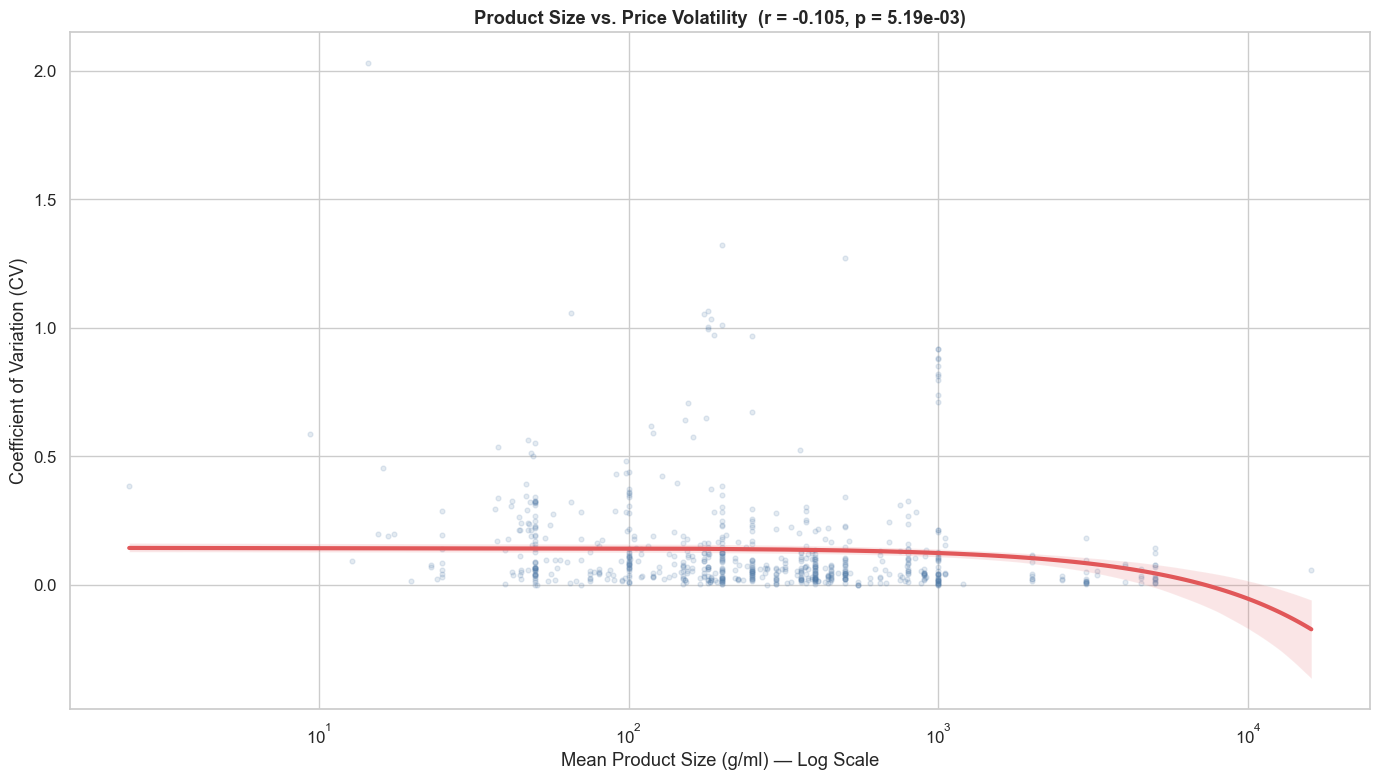

In [2]:
product_stats = df.groupby('product_id').agg(
    mean_size  = ('size_normalized', 'mean'),
    mean_price = ('price_clean', 'mean'),
    std_price  = ('price_clean', 'std'),
).dropna()
product_stats['cv'] = product_stats['std_price'] / product_stats['mean_price']
product_stats = product_stats[product_stats['mean_size'] > 0]

r, p = pearsonr(product_stats['mean_size'], product_stats['cv'])
print(f'Pearson r = {r:.4f} | p-value = {p:.2e}')

fig, ax = plt.subplots(figsize=(14, 8))
sns.regplot(data=product_stats, x='mean_size', y='cv', ax=ax,
            scatter_kws={'alpha':0.15, 's':12, 'color':'#4e79a7'},
            line_kws={'color':'#e15759', 'lw':3})
ax.set_xscale('log')
ax.set_title(f'Product Size vs. Price Volatility  (r = {r:.3f}, p = {p:.2e})', fontweight='bold')
ax.set_xlabel('Mean Product Size (g/ml) — Log Scale')
ax.set_ylabel('Coefficient of Variation (CV)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_size_vs_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

## 7.2 — Competitors vs Price Spread

Pearson r = 0.0109 | p-value = 7.68e-01


C:\Users\Nouman\AppData\Local\Temp\ipykernel_18712\800071796.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=comp_stats, x='num_stores', y='price_spread', ax=ax,


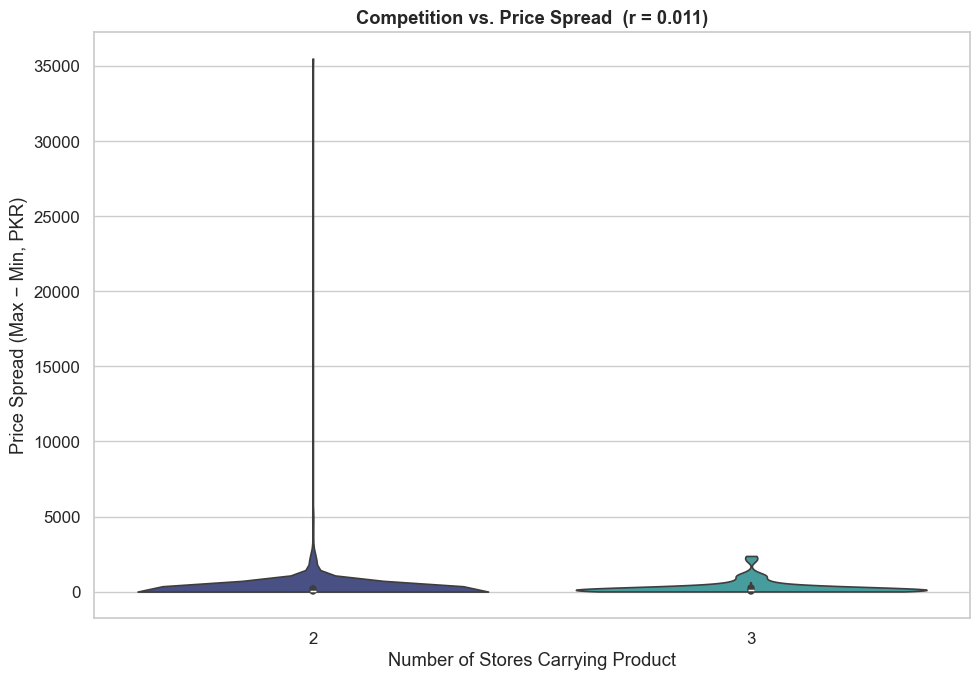

In [3]:
comp_stats = df.groupby('product_id').agg(
    num_stores   = ('store_name', 'nunique'),
    price_spread = ('price_clean', lambda x: x.max() - x.min())
).reset_index()

r2, p2 = pearsonr(comp_stats['num_stores'], comp_stats['price_spread'])
print(f'Pearson r = {r2:.4f} | p-value = {p2:.2e}')

fig, ax = plt.subplots(figsize=(10, 7))
sns.violinplot(data=comp_stats, x='num_stores', y='price_spread', ax=ax,
               palette='mako', inner='box', linewidth=1.2, cut=0)
ax.set_title(f'Competition vs. Price Spread  (r = {r2:.3f})', fontweight='bold')
ax.set_xlabel('Number of Stores Carrying Product')
ax.set_ylabel('Price Spread (Max − Min, PKR)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_competition_spread.png', dpi=150, bbox_inches='tight')
plt.show()

## 7.3 — City-Wise Price Correlation (Clustered Heatmap)

<Figure size 1200x1000 with 0 Axes>

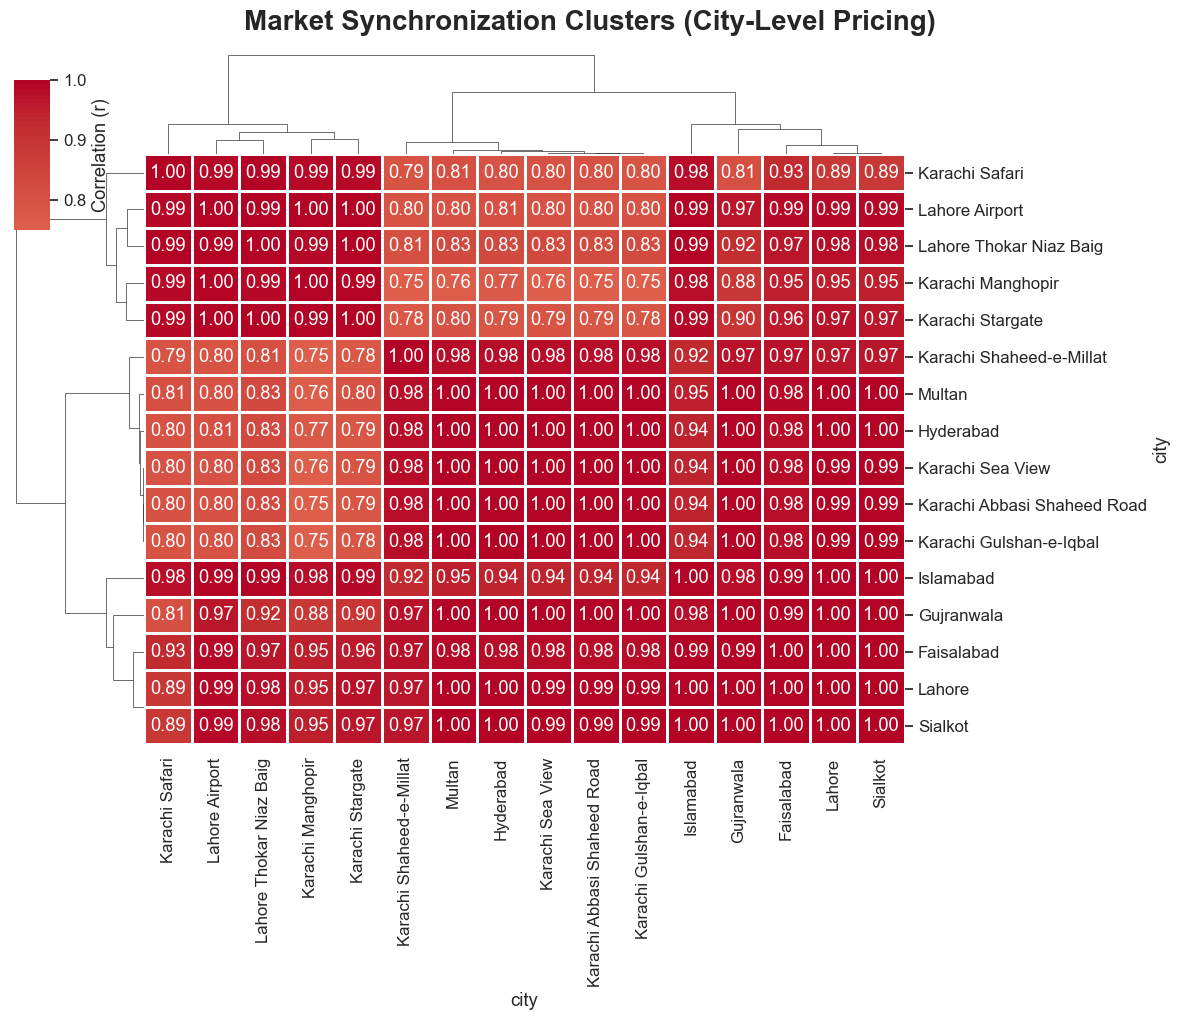

In [4]:
# Professional Hierarchical Clustermap (City-Level Market Behavior)
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate local correlations to ensure 'city_corr' is defined
city_prices = df.groupby(['city', 'product_id'])['price_clean'].mean().unstack(level=0)
city_corr = city_prices.corr()

plt.figure(figsize=(12, 10))
g = sns.clustermap(
    city_corr, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    center=0,
    linewidths=.75, 
    figsize=(12, 10),
    dendrogram_ratio=0.15,
    cbar_pos=(0.02, 0.8, 0.03, 0.15),
    cbar_kws={'label': 'Correlation (r)'}
)
g.fig.suptitle("Market Synchronization Clusters (City-Level Pricing)", y=1.02, fontsize=20, fontweight='bold')
plt.savefig(FIGURES_DIR / '04_city_clustermap.png', dpi=300, bbox_inches='tight')
plt.show()

## 7.4 — Cross-Store Price Synchronization (Spearman)

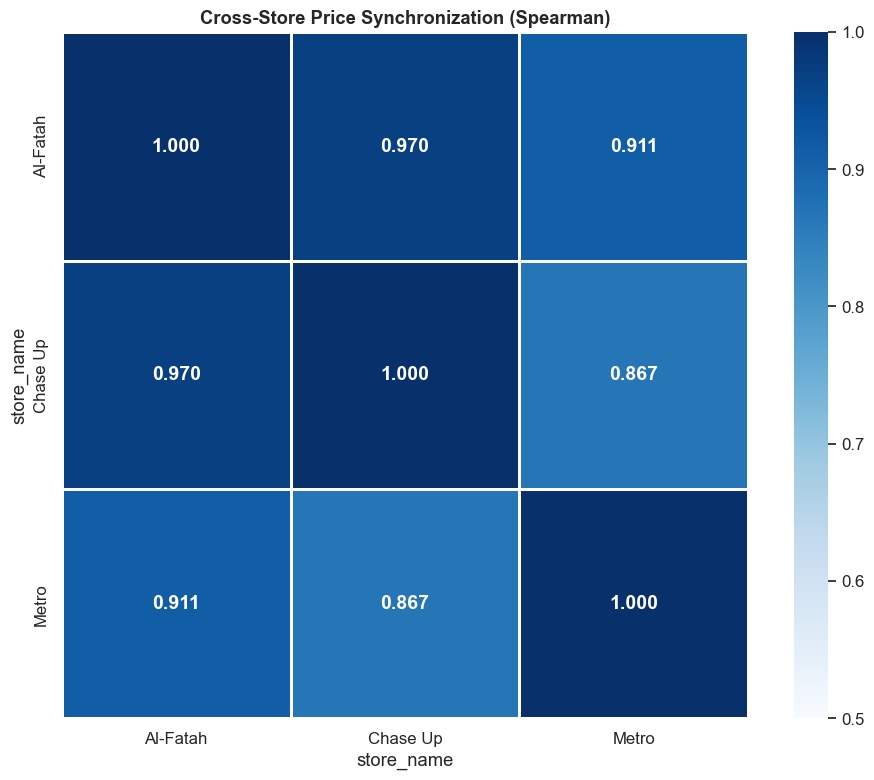

Spearman ~ 1.0 = Stores rank products similarly (synchronized pricing)


In [5]:
store_pivot = df.pivot_table(index='product_id', columns='store_name', values='price_clean', aggfunc='mean')
store_corr  = store_pivot.corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(store_corr, annot=True, fmt='.3f', cmap='Blues', linewidths=2,
            ax=ax, vmin=0.5, vmax=1.0, square=True,
            annot_kws={'fontsize':14, 'fontweight':'bold'})
ax.set_title('Cross-Store Price Synchronization (Spearman)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_store_sync.png', dpi=150, bbox_inches='tight')
plt.show()
print('Spearman ~ 1.0 = Stores rank products similarly (synchronized pricing)')

## 7.5 — Correlation Summary

In [6]:
summary = pd.DataFrame([
    {'Correlation': 'Size vs Price Dispersion',    'Method': 'Pearson',  'r': round(r,4),  'p-value': f'{p:.2e}'},
    {'Correlation': 'Competitors vs Price Spread', 'Method': 'Pearson',  'r': round(r2,4), 'p-value': f'{p2:.2e}'},
])
print('=== Correlation Summary ===')
display(summary)

=== Correlation Summary ===


,Correlation,Method,r,p-value
0,Size vs Price Dispersion,Pearson,-0.1052,5.19e-03
1,Competitors vs Price Spread,Pearson,0.0109,7.68e-01


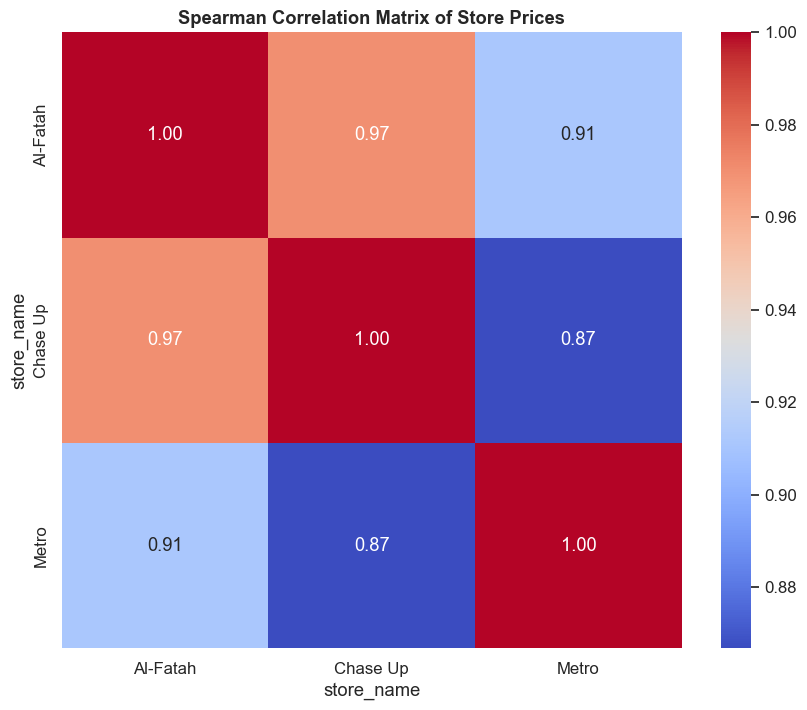

In [7]:
# Spearman Correlation Analysis (Mandatory Sec 3.4)
# Captures non-linear monotonic relationships between prices
from scipy.stats import spearmanr

# Pivot data for correlation analysis
pivoted_prices = df.pivot_table(index='product_id', columns='store_name', values='price_clean')
corr_matrix_spearman = pivoted_prices.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_spearman, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Spearman Correlation Matrix of Store Prices")
plt.show()

In [8]:
# Price Synchronization Analysis (Sec 3.4)
# Analyzing how closely price movements are linked across stores
# We calculate the average correlation coefficient across all store pairs

avg_sync = corr_matrix_spearman.where(np.triu(np.ones(corr_matrix_spearman.shape), k=1).astype(bool)).stack().mean()
print(f"Overall Market Price Synchronization Score: {avg_sync:.4f}")
print("(1.0 = Perfect synchronization, 0.0 = No link)")

Overall Market Price Synchronization Score: 0.9161
(1.0 = Perfect synchronization, 0.0 = No link)
